# Building Neural Networks

## Goal

Build a neural network from scratch to understand how neural networks learn from data, update their parameters, and make predictions.

The project starts from the simplest possible model and evolves step by step toward multiclass classification, hidden layers, mini-batch training, and deeper networks.

---

## Version 1

Build the simplest possible neural network: a single neuron for binary image classification.

The model will:

- use Fashion-MNIST images as input
- keep only two classes for a binary classification problem
- normalize pixel values
- compute a weighted sum of the input pixels
- convert the result into a probability with the sigmoid function
- measure the error with binary cross-entropy
- update weights and bias with gradient descent
- repeat training until the loss stops improving
- convert probabilities into binary predictions
- evaluate the final accuracy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/"

train = pd.read_csv(PATH + "fashion-mnist_train.csv")
test  = pd.read_csv(PATH + "fashion-mnist_test.csv")

In [3]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [5]:
# Separate pixels from labels

X = train.drop(columns="label").values
y = train["label"].values

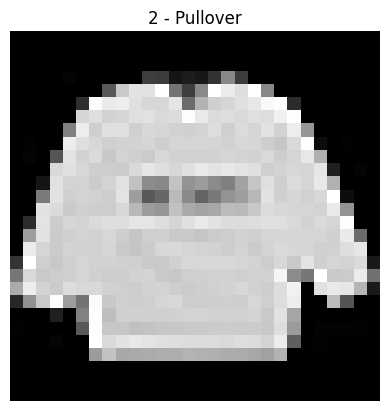

In [6]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"{y[0]} - {labels[y[0]]}")
plt.axis("off")
plt.show()

## Data preparation

We prepare the image pixels and target labels for a simple binary classification problem.

In [7]:
# Keep only T-shirt/top (0) and Trouser (1)
mask = (y == 0) | (y == 1)

X = X[mask]
y = y[mask]

# Normalize pixel values from 0-255 to 0-1
X = X / 255.0

## Building the model

We now build a single neuron from scratch, starting from the weighted input and gradually adding probability prediction and learning.

### Sigmoid activation

The sigmoid function converts the raw neuron output into a value between `0` and `1`.

In [8]:
# Convert the raw neuron output into a probability

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [9]:
def train(X, y, w, b, lr=0.1, tol=1e-6):
    previous_loss = float("inf")

    while True:
        z = X @ w + b
        pred = sigmoid(z)

        loss = -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))

        if previous_loss - loss < tol:
            break

        previous_loss = loss

        dw = X.T @ (pred - y) / len(y)
        db = np.mean(pred - y)

        w = w - lr * dw
        b = b - lr * db

    return w, b, loss

In [10]:
# Initialize 784 weights and one bias

w = np.zeros(X.shape[1])
b = 0.0

### Training

The neuron repeatedly measures its prediction error and updates the weights and bias to reduce the loss.

In [11]:
w, b, loss = train(X, y, w, b)

print(f"Train loss: {loss:.4f}")

Train loss: 0.0305


## Evaluation

The trained neuron converts probabilities into binary predictions using a threshold of `0.5`.

In [12]:
z = X @ w + b
pred = sigmoid(z)

y_pred = (pred >= 0.5).astype(int)
accuracy = np.mean(y_pred == y)

print(f"Train accuracy: {accuracy:.2%}")

Train accuracy: 98.97%


In [13]:
X_test = test.drop(columns="label").values / 255.0
y_test = test["label"].values

mask = (y_test == 0) | (y_test == 1)

X_test = X_test[mask]
y_test = y_test[mask]

pred = sigmoid(X_test @ w + b)
preds = (pred >= 0.5).astype(int)

accuracy = np.mean(preds == y_test)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 99.15%


## Notes

This first version implements a single neuron for binary image classification.

- Only classes `0` (T-shirt/top) and `1` (Trouser) are used.
- Images are flattened into 784 pixel values and normalized to `0-1`.
- The sigmoid converts the neuron output into a probability.
- Binary cross-entropy measures the error.
- Gradient descent updates weights and bias.
- Final predictions use a threshold of `0.5`.
- The model reaches about `98.97%` training accuracy and `99.15%` test accuracy on this binary task.
- This version does not yet classify all 10 Fashion-MNIST classes.

Future versions will introduce new components and gradually evolve the architecture.